# EDA on raw data

Exploration of `data/RTA Dataset.csv` before any cleaning or feature engineering.
The goal here is to understand data quality issues, missingness patterns, and
raw distributions — not to make decisions yet.

Color convention: Fatal injury = red, Serious Injury = yellow, Slight Injury = green.


## Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

SEVERITY_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]
SEVERITY_COLORS = {
    "Slight Injury":  "#2ca02c",
    "Serious Injury": "#f1c40f",
    "Fatal injury":   "#d62728",
}
SEVERITY_PALETTE = [SEVERITY_COLORS[s] for s in SEVERITY_ORDER]


In [2]:
def severity_crosstab(s, target):
    pivot = pd.crosstab(s, target)
    for col in SEVERITY_ORDER:
        if col not in pivot.columns:
            pivot[col] = 0
    return pivot[SEVERITY_ORDER]


def plot_count_and_pct(series, target, title, order=None, rotation=0, figsize=(12, 4)):
    pivot = severity_crosstab(series, target)
    if order is not None:
        pivot = pivot.reindex([o for o in order if o in pivot.index])

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    pivot.plot(kind="bar", stacked=True, color=SEVERITY_PALETTE, ax=axes[0])
    axes[0].set_title(f"{title} — count")
    axes[0].set_ylabel("Number of accidents")
    axes[0].tick_params(axis="x", rotation=rotation)
    axes[0].grid(axis="y", linestyle="--", alpha=0.4)

    pct = pivot.div(pivot.sum(axis=1).replace(0, np.nan), axis=0)
    pct.plot(kind="bar", stacked=True, color=SEVERITY_PALETTE, ax=axes[1])
    axes[1].set_title(f"{title} — percentage")
    axes[1].set_ylabel("Share within group")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=rotation)
    axes[1].grid(axis="y", linestyle="--", alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].get_legend().remove()
    axes[1].legend(handles, labels, title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## Load and initial look

In [3]:
df = pd.read_csv("data/RTA Dataset.csv")
target = df["Accident_severity"]
print("shape:", df.shape)
df.head(3)

shape: (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury


In [4]:
# Column overview: dtype, unique count, and NaN.
pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=False),
    "n_nan": df.isna().sum(),
    "nan_pct": (df.isna().mean() * 100).round(1),
}).sort_values("n_nan", ascending=False)

,dtype,n_unique,n_nan,nan_pct
Defect_of_vehicle,str,4,4427,35.9
Service_year_of_vehicle,str,7,3928,31.9
Work_of_casuality,str,8,3198,26.0
Fitness_of_casuality,str,6,2635,21.4
Type_of_vehicle,str,18,950,7.7
Types_of_Junction,str,9,887,7.2
Driving_experience,str,8,829,6.7
Educational_level,str,8,741,6.0
Vehicle_driver_relation,str,5,579,4.7
Owner_of_vehicle,str,5,482,3.9


## Target distribution

Three-class ordinal outcome. Fatal injury is rare (~1.3%) — class imbalance handling
is mandatory for any classifier.


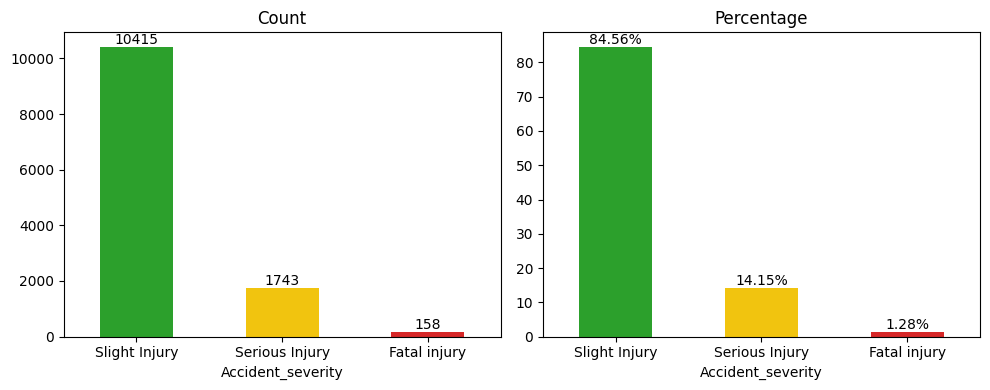

,count,pct_%
Accident_severity,,
Slight Injury,10415,84.56
Serious Injury,1743,14.15
Fatal injury,158,1.28


In [5]:
counts = target.value_counts().reindex(SEVERITY_ORDER)
pct = (counts / counts.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts.plot(kind="bar", color=SEVERITY_PALETTE, ax=axes[0])
axes[0].set_title("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

pct.plot(kind="bar", color=SEVERITY_PALETTE, ax=axes[1])
axes[1].set_title("Percentage")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(pct):
    axes[1].text(i, v, f"{v}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()
pd.DataFrame({"count": counts, "pct_%": pct})

## Missingness

Two forms of missing data:
- True NaN in the CSV — needs imputation or 'Unknown' fill.
- Soft-missing strings: `Unknown`, `Missing`, `na`, `other` (lowercase) — inconsistent
  encoding that needs normalisation.


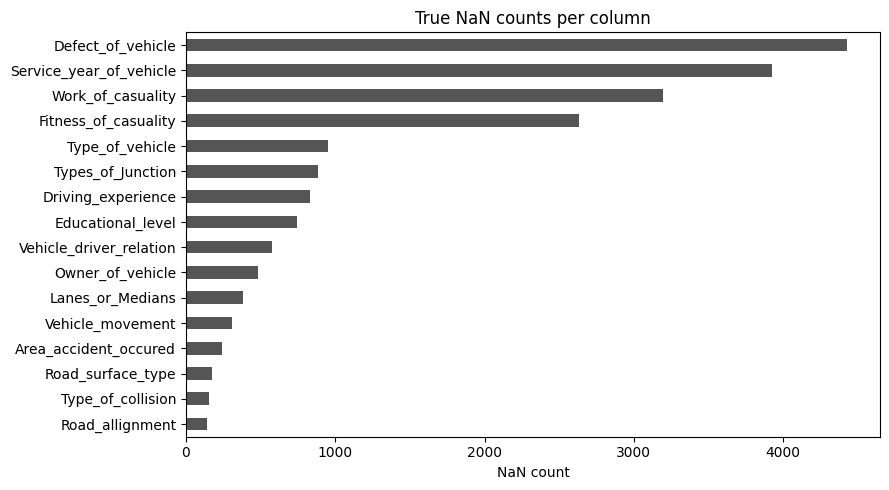

Defect_of_vehicle          4427
Service_year_of_vehicle    3928
Work_of_casuality          3198
Fitness_of_casuality       2635
Type_of_vehicle             950
Types_of_Junction           887
Driving_experience          829
Educational_level           741
Vehicle_driver_relation     579
Owner_of_vehicle            482
Lanes_or_Medians            385
Vehicle_movement            308
Area_accident_occured       239
Road_surface_type           172
Type_of_collision           155
Road_allignment             142
dtype: int64

In [6]:
nan_counts = df.isna().sum().sort_values(ascending=False)
nan_counts = nan_counts[nan_counts > 0]

fig, ax = plt.subplots(figsize=(9, 5))
nan_counts.plot(kind="barh", ax=ax, color="#555")
ax.set_title("True NaN counts per column")
ax.set_xlabel("NaN count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
nan_counts

In [7]:
# Soft-missing token counts per column.
SOFT = {"Unknown", "unknown", "Missing", "missing", "na", "Na", "NA", "other"}
soft = [(c, int(df[c].isin(SOFT).sum()))
        for c in df.columns
        if str(df[c].dtype) in ("object", "str", "string")]
soft = [(c, n) for c, n in soft if n > 0]
pd.DataFrame(soft, columns=["column", "soft_missing"]).sort_values(
    "soft_missing", ascending=False).reset_index(drop=True)

,column,soft_missing
0,Casualty_severity,4443
1,Age_band_of_casualty,4443
2,Casualty_class,4443
3,Sex_of_casualty,4443
4,Service_year_of_vehicle,2883
5,Lanes_or_Medians,1717
6,Age_band_of_driver,1548
7,Weather_conditions,292
8,Types_of_Junction,191
9,Sex_of_driver,178


## Time features

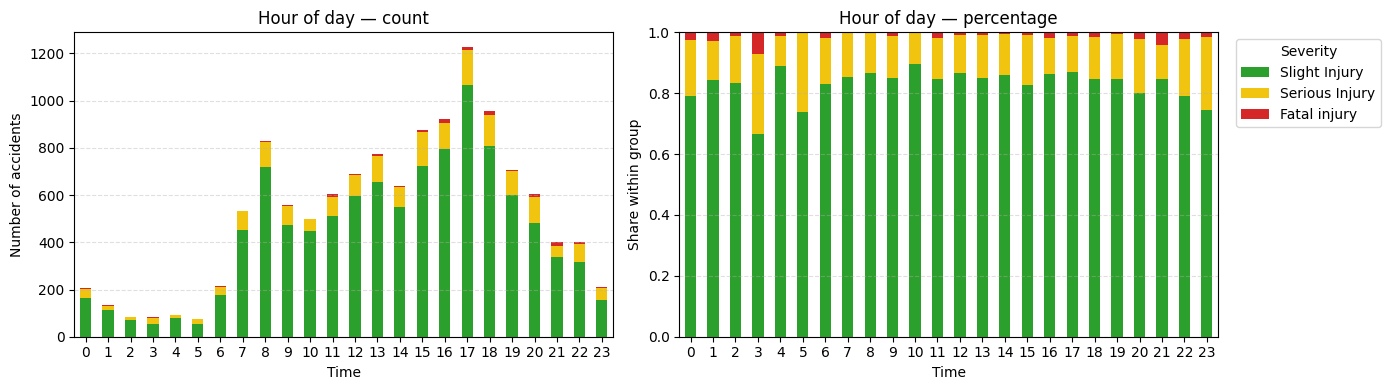

In [8]:
hour = pd.to_datetime(df["Time"], format="%H:%M:%S", errors="coerce").dt.hour
plot_count_and_pct(hour, target, "Hour of day", figsize=(14, 4))

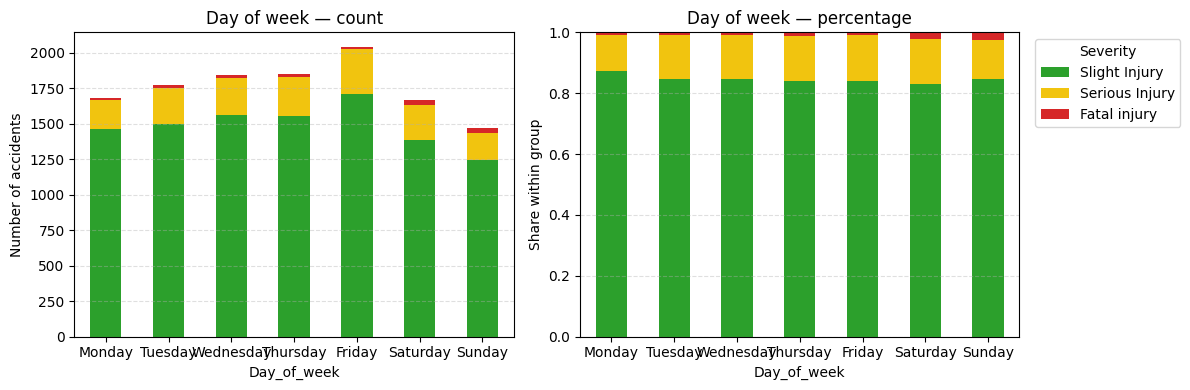

In [9]:
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plot_count_and_pct(df["Day_of_week"], target, "Day of week", order=DAY_ORDER)

## Driver features

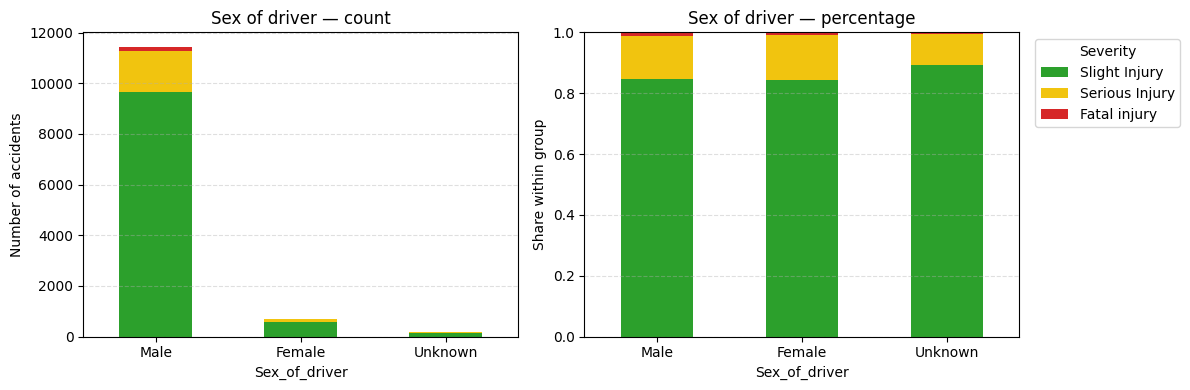

In [10]:
plot_count_and_pct(df["Sex_of_driver"], target, "Sex of driver",
                   order=["Male", "Female", "Unknown"])

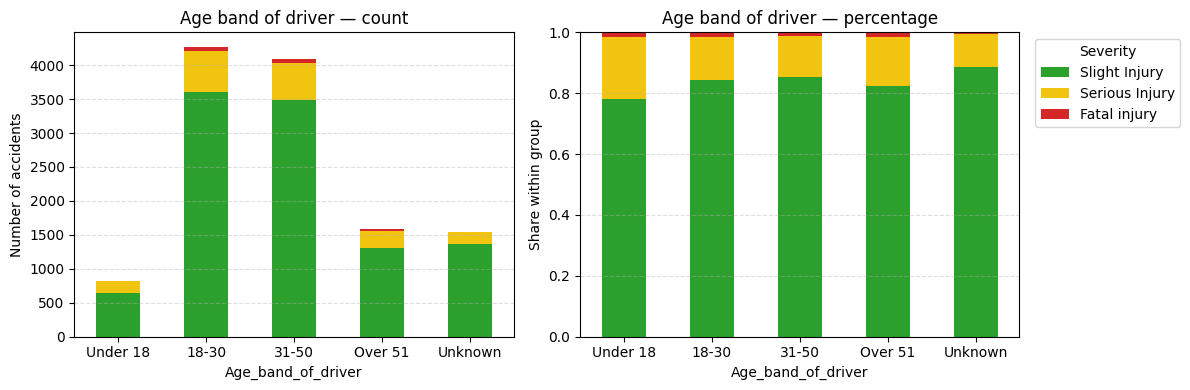

In [11]:
plot_count_and_pct(df["Age_band_of_driver"], target, "Age band of driver",
                   order=["Under 18", "18-30", "31-50", "Over 51", "Unknown"])

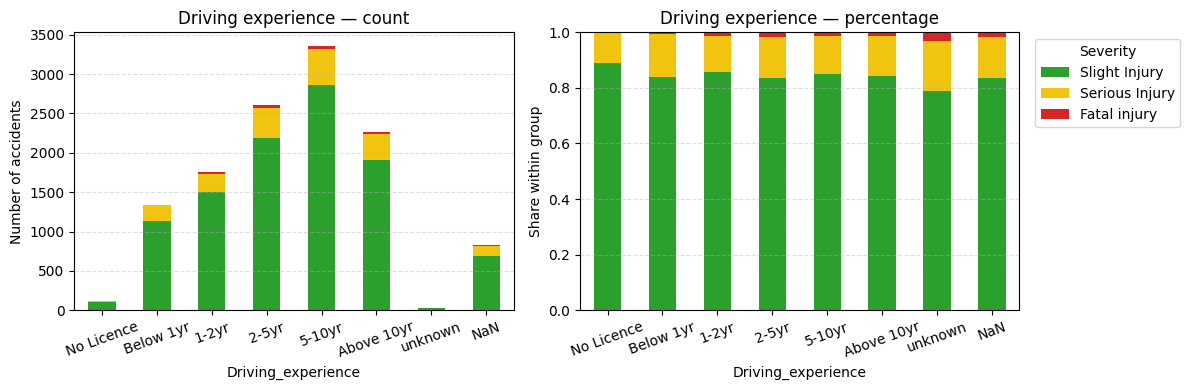

In [12]:
# Note: lowercase 'unknown' (33 rows) alongside proper 'Unknown' — casing bug.
EXP_ORDER = ["No Licence", "Below 1yr", "1-2yr", "2-5yr", "5-10yr", "Above 10yr", "unknown"]
plot_count_and_pct(df["Driving_experience"].fillna("NaN"), target,
                   "Driving experience", order=EXP_ORDER + ["NaN"], rotation=20)

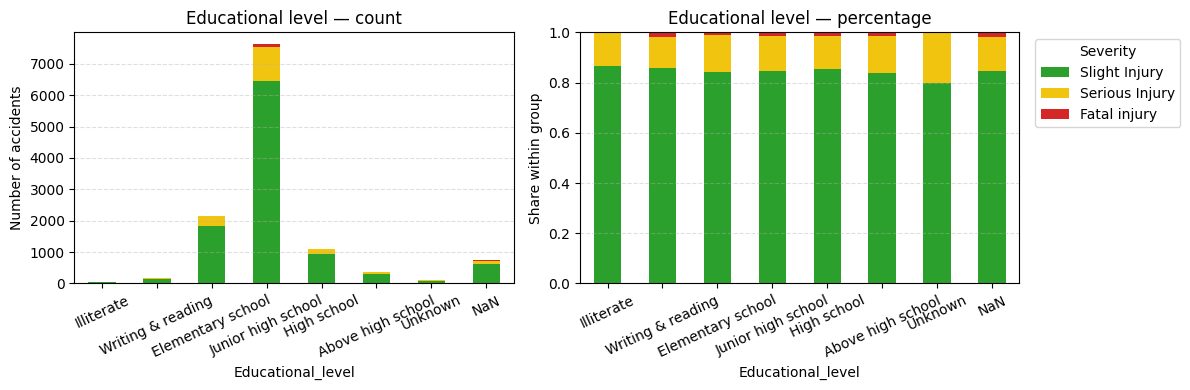

In [13]:
EDU_ORDER = ["Illiterate", "Writing & reading", "Elementary school",
             "Junior high school", "High school", "Above high school", "Unknown"]
plot_count_and_pct(df["Educational_level"].fillna("NaN"), target,
                   "Educational level", order=EDU_ORDER + ["NaN"], rotation=25)

## Vehicle features

`Type_of_vehicle` contains `?` encoding artifacts (e.g. `Lorry (41?100Q)` should be
`Lorry (41-100Q)`). `Defect_of_vehicle` is 36% NaN with nonsensical integer codes (5, 7) —
it is dropped in cleaning.


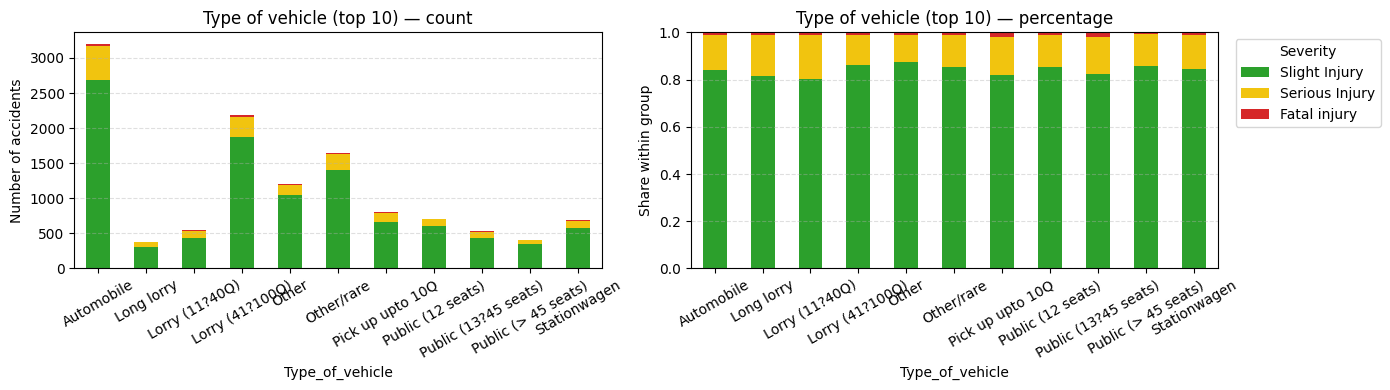

In [14]:
top_types = df["Type_of_vehicle"].value_counts().head(10).index
plot_count_and_pct(
    df["Type_of_vehicle"].where(df["Type_of_vehicle"].isin(top_types), "Other/rare"),
    target, "Type of vehicle (top 10)", rotation=30, figsize=(14, 4))

In [15]:
print("Defect_of_vehicle values:")
print(df["Defect_of_vehicle"].value_counts(dropna=False))

Defect_of_vehicle values:
Defect_of_vehicle
No defect    7777
NaN          4427
7              76
5              36
Name: count, dtype: int64


## Road and environmental features

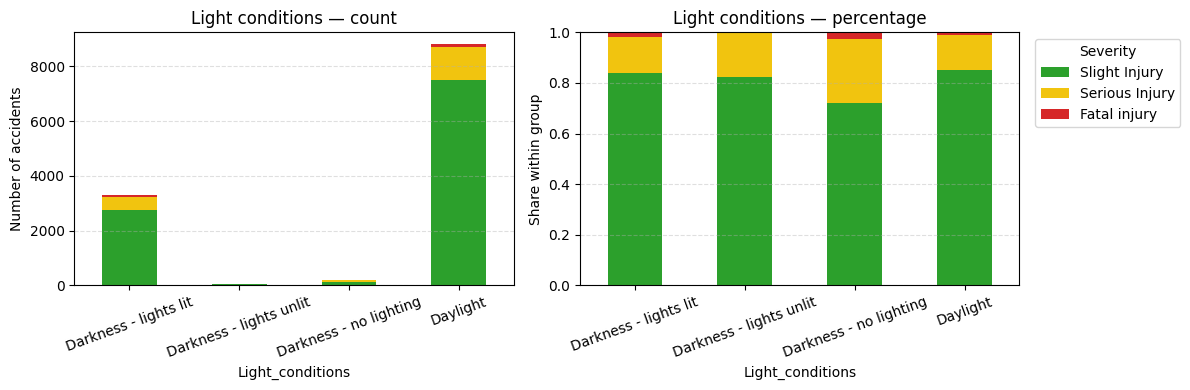

In [16]:
plot_count_and_pct(df["Light_conditions"], target, "Light conditions", rotation=20)

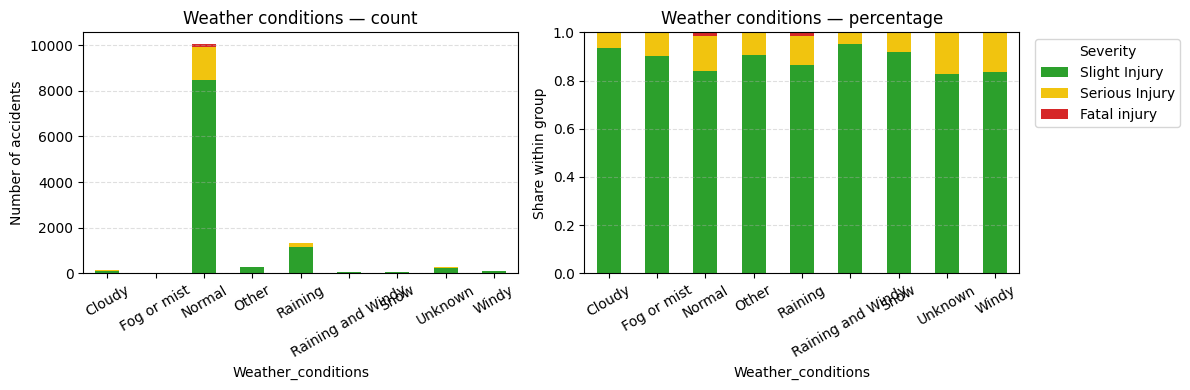

In [17]:
plot_count_and_pct(df["Weather_conditions"], target, "Weather conditions", rotation=30)

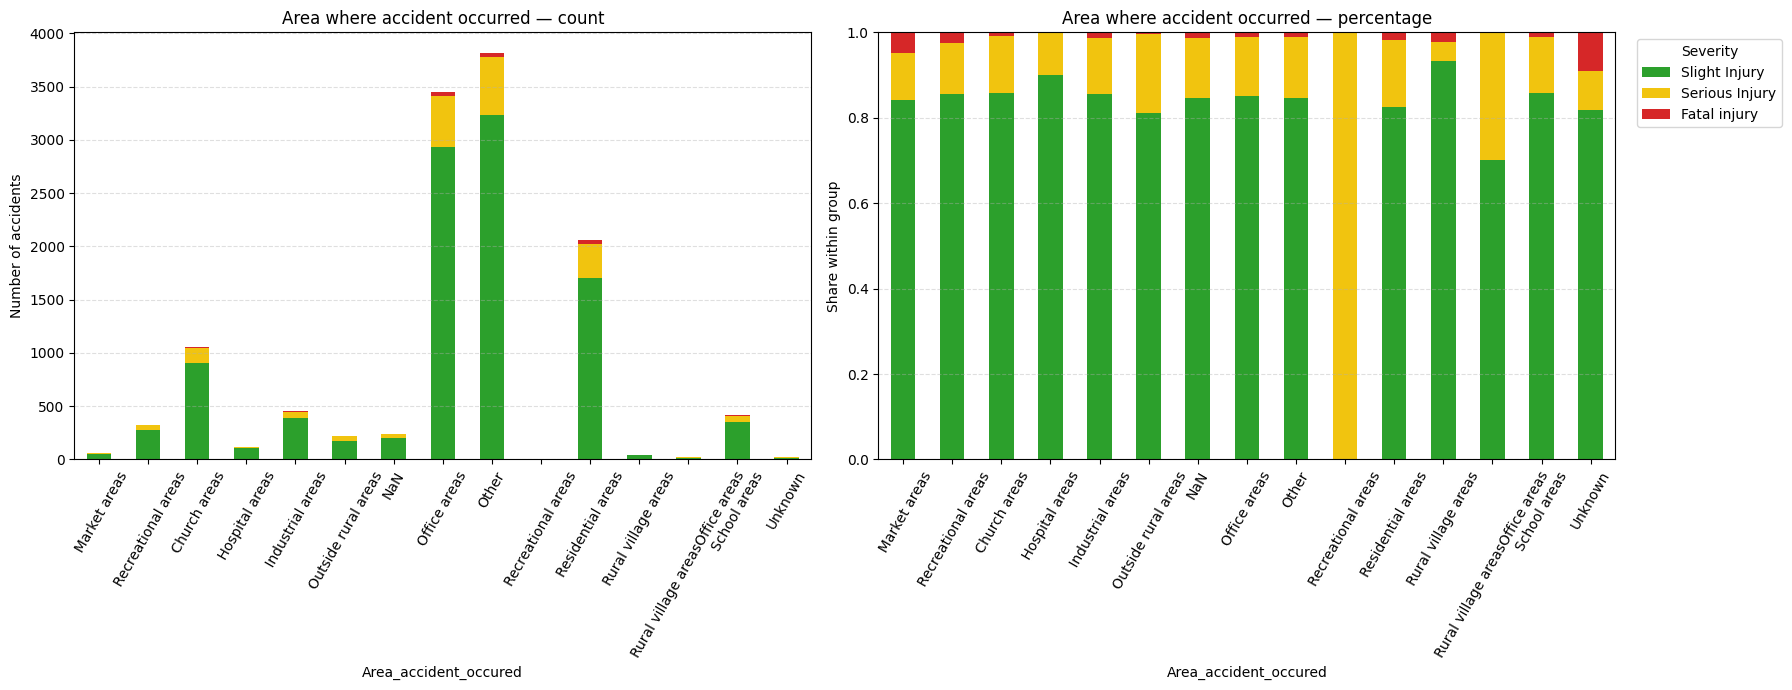

In [26]:
# Note leading whitespace: ' Church areas', ' Industrial areas' etc.
# 'Rural village areasOffice areas' is a glued-together concatenation (20 rows).
plot_count_and_pct(
    df["Area_accident_occured"].fillna("NaN"),
    target,
    "Area where accident occurred",
    rotation=60,
    figsize=(18, 7)
)

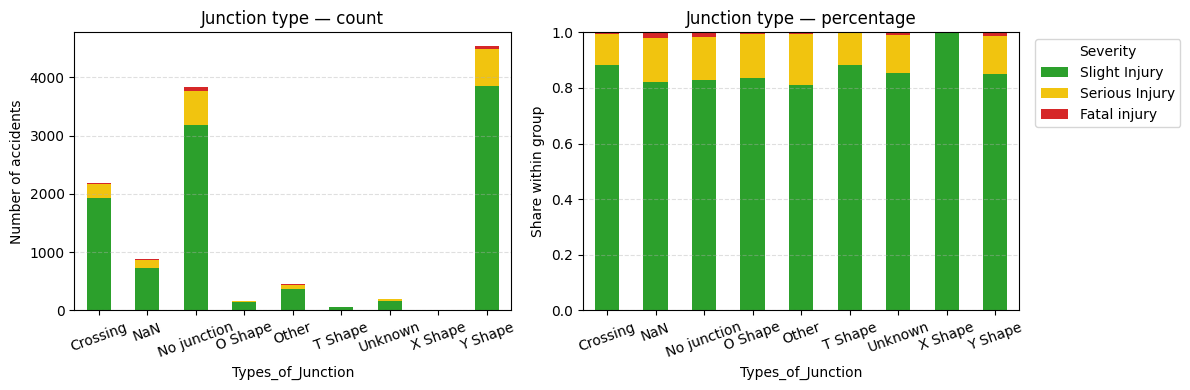

In [19]:
plot_count_and_pct(df["Types_of_Junction"].fillna("NaN"), target,
                   "Junction type", rotation=20)

## Collision features

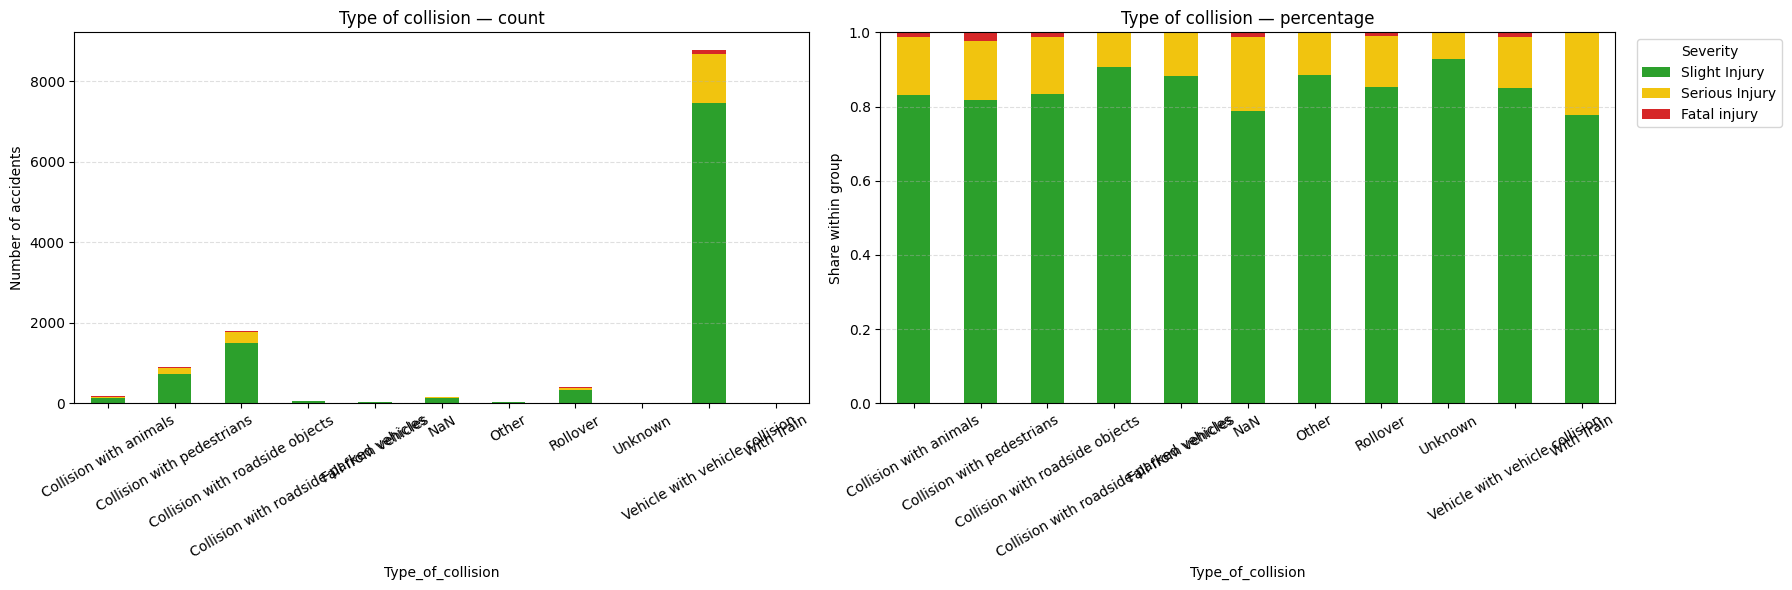

In [29]:
plot_count_and_pct(df["Type_of_collision"].fillna("NaN"), target,
                   "Type of collision", rotation=30, figsize=(18, 6))

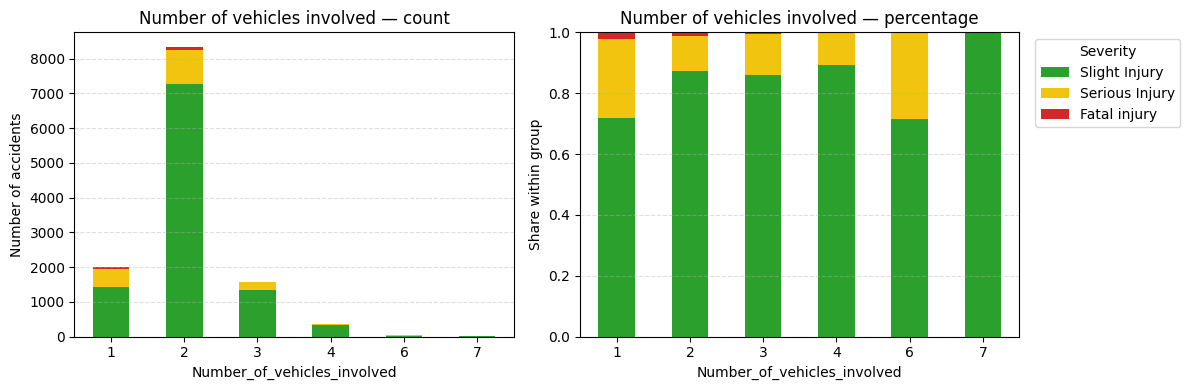

In [21]:
plot_count_and_pct(df["Number_of_vehicles_involved"], target,
                   "Number of vehicles involved")

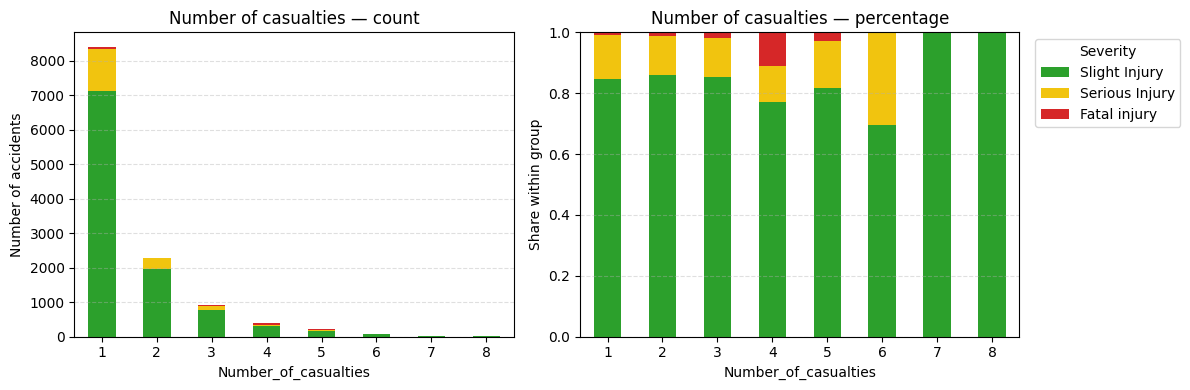

In [22]:
plot_count_and_pct(df["Number_of_casualties"], target,
                   "Number of casualties")

## Casualty features

These are post-hoc records filled in after the accident. The `na` string marks 4,443
records with no associated casualty entry. `Casualty_severity` is direct target leakage
and is dropped. The rest carry almost no predictive signal — see EDA_cleaned.ipynb
for the analysis confirming this.


In [23]:
# Casualty_class severity distribution — nearly identical across all groups.
print(pd.crosstab(df["Casualty_class"], target, normalize="index").mul(100).round(1))

Accident_severity  Fatal injury  Serious Injury  Slight Injury
Casualty_class                                                
Driver or rider             1.4            14.5           84.0
Passenger                   0.9            14.2           84.8
Pedestrian                  1.6            13.8           84.5
na                          1.1            13.8           85.1


In [24]:
# Pedestrian_movement has a text-replacement corruption.
# 'na' was globally replaced with 'Not a Pedestrian', mangling 'stationary'
# into 'statioNot a Pedestrianry' in 468 rows.
corrupted = df["Pedestrian_movement"].fillna("").str.contains("statioNot a Pedestrianry")
print(f"Corrupted Pedestrian_movement rows: {corrupted.sum()}")
df["Pedestrian_movement"].value_counts().head(6)

Corrupted Pedestrian_movement rows: 468


Pedestrian_movement
Not a Pedestrian                                                                  11390
Crossing from nearside - masked by parked or statioNot a Pedestrianry vehicle       337
Unknown or other                                                                    293
Crossing from driver's nearside                                                     140
Crossing from offside - masked by  parked or statioNot a Pedestrianry vehicle        72
In carriageway, statioNot a Pedestrianry - not crossing  (standing or playing)       46
Name: count, dtype: int64

## Cause of accident

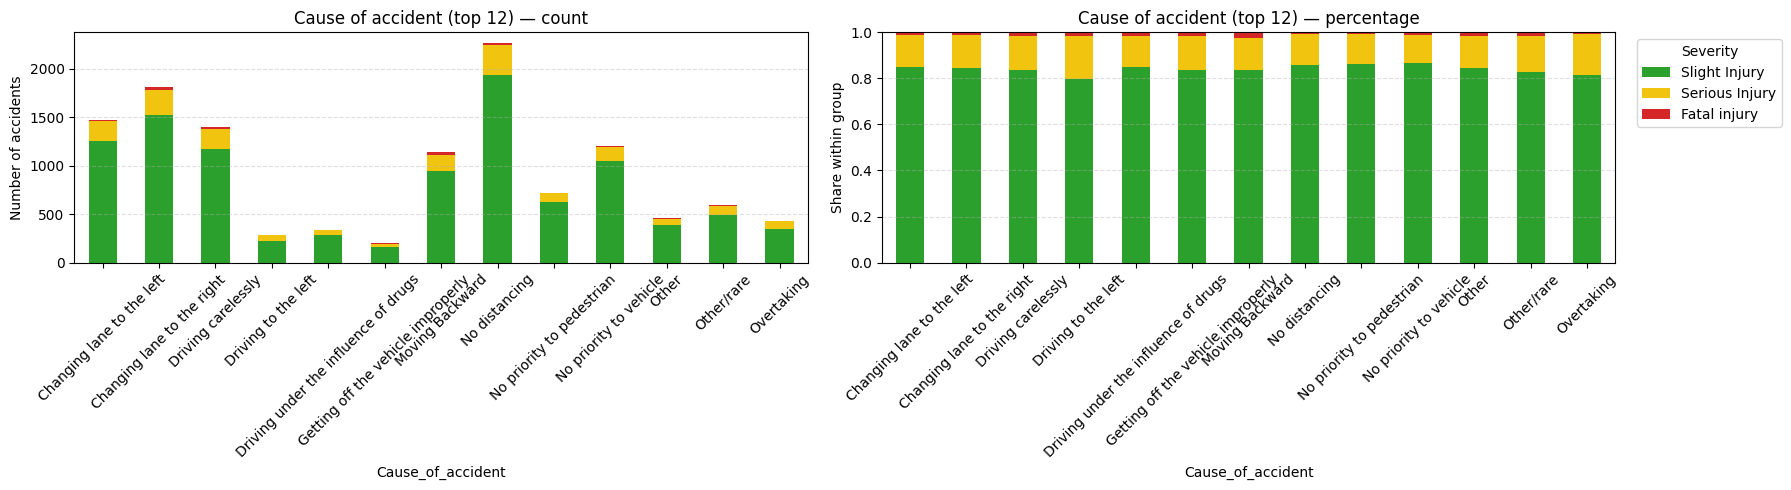

In [30]:
cause_top = df["Cause_of_accident"].value_counts().head(12).index
plot_count_and_pct(
    df["Cause_of_accident"].where(df["Cause_of_accident"].isin(cause_top), "Other/rare"),
    target, "Cause of accident (top 12)", rotation=45, figsize=(18, 5))

## Data quality issues found

Issues to address in cleaning (handled by `clean-feature-engineer.py`):

| Column | Issue |
|---|---|
| `Defect_of_vehicle` | 36% NaN + integer codes (5, 7) — drop |
| `Casualty_severity` | Target leakage — drop |
| Casualty group | Post-hoc, zero predictive signal — drop all 6 columns |
| `Pedestrian_movement` | `statioNot a Pedestrianry` corruption in 468 rows |
| `Type_of_vehicle` | `?` encoding artifact for `-` |
| `Fitness_of_casuality` | `NormalNormal` typo (19 rows) |
| `Area_accident_occured` | Leading whitespace; `Rural village areasOffice areas` glitch (20 rows) |
| `Driving_experience` | Lowercase `unknown` (33 rows) |
| `Lanes_or_Medians` | Lowercase `other` (1660 rows) |
| `Age_band_of_casualty` | Invalid value `5` (244 rows) |
| All string cols | True NaN -> 'Unknown'; `na` string -> 'Unknown' |
